In [58]:
base_dir = '/scratch/mjehangir/manuscript_figures/manuscript_data/'
setwd(base_dir)

In [59]:
# Load required libraries
library(tidyverse)
library(corrplot)
library(ggpubr)
library(tidyverse)
library(readxl)
library(DESeq2)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(ggrepel)
library(ComplexHeatmap)
library(tidyr)
library(dplyr)
library(GGally)
library(data.table)  # For fread()

In [229]:
final_df = read.csv(file = "final_merged_for_correlation_analysis_v3.tsv", header = TRUE, sep = "\t")
final_df2 = read.csv(file = "final_merged_for_correlation_analysis_v2.tsv", header = TRUE, sep = "\t")


In [230]:
nrow(final_df)

[1] 1155

In [231]:
final_df <- final_df %>%
  arrange(SampleID)
final_df2 <- final_df2 %>%
  arrange(SampleID)

In [232]:
head(final_df, n=2)
head(final_df2, n=2)

,SampleID,assigned_arm,chr,Length,total_length_neutral,total_length_gain,total_length_loss,proportion_neutral,proportion_gain,proportion_loss,final_average_TL_p75,chr_order,arm,arm_call,arm_num_seg,arm_cr_wmean,type,total_size,SVs_density
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,2436A,chr10q,chr10,94108943,26230785,0,18621836,0.2787279,0,0.1978753,2732.75,10,q,0,5,0.9870386,DEL,159358,0.0016933354
2,2436A,chr10q,chr10,94108943,26230785,0,18621836,0.2787279,0,0.1978753,2732.75,10,q,0,5,0.9870386,DUP,23673,0.0002515489


,SampleID,chr,arm,SV_density,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,INS_density,DEL_density,DUP_density,INV_density,BND_density
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,2436A,chr10,q,0.17198792,0,0.1978753,2732.75,0,5,0.9870386,0,0.17162199,0.0003659318,0,0
2,2436A,chr11,p,0.04256577,0,0.0000000,6766.00,0,6,1.0067300,0,0.04256577,0.0000000000,0,0


In [233]:
nrow(final_df)
nrow(final_df2)

[1] 1155

[1] 555

In [236]:
unique(final_df$type)

[1] "DEL" "DUP" "INV" "INS"

In [237]:
library(dplyr)
library(tidyr)

final_df2_converted <- final_df %>%
  # 1. Select & rename the density column up front
  select(
    SampleID,
    chr,
    arm,
    SV_density   = SVs_density,
    proportion_gain,
    proportion_loss,
    final_average_TL_p75,
    arm_call,
    arm_num_seg,
    arm_cr_wmean,
    type
  ) 

In [238]:
head(final_df2_converted)

,SampleID,chr,arm,SV_density,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,type
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<chr>
1,2436A,chr10,q,0.0016933354,0,0.1978753,2732.75,0,5,0.9870386,DEL
2,2436A,chr10,q,0.0002515489,0,0.1978753,2732.75,0,5,0.9870386,DUP
3,2436A,chr11,p,0.0019771037,0,0.0000000,6766.00,0,6,1.0067300,DEL
4,2436A,chr12,p,0.0018935909,0,0.0000000,5319.40,0,2,1.0909572,DEL
5,2436A,chr12,p,2.7773186171,0,0.0000000,5319.40,0,2,1.0909572,INV
6,2436A,chr12,q,0.0016849003,0,0.0000000,6085.00,0,10,1.0029376,DEL


In [239]:
final_df2_converted = final_df2_converted %>% pivot_wider(
    names_from   = type,
    values_from  = SV_density,
    names_glue   = "{type}_density",
    values_fill  = 0
  ) 

In [240]:
head(final_df2_converted)

SampleID,chr,arm,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,DEL_density,DUP_density,INV_density,INS_density
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr10,q,0.00000000,0.1978753,2732.75,0,5,0.9870386,0.001693335,0.0002515489,0.0000000,0
2436A,chr11,p,0.00000000,0.0000000,6766.00,0,6,1.0067300,0.001977104,0.0000000000,0.0000000,0
2436A,chr12,p,0.00000000,0.0000000,5319.40,0,2,1.0909572,0.001893591,0.0000000000,2.7773186,0
2436A,chr12,q,0.00000000,0.0000000,6085.00,0,10,1.0029376,0.001684900,0.0000000000,0.2194209,0
2436A,chr14,q,0.00000000,0.0000000,3490.60,0,11,1.0114610,0.001365601,0.0000000000,0.0000000,0
2436A,chr15,q,0.01940815,0.0000000,4111.50,0,3,0.9820486,0.001244814,0.0000000000,0.0000000,0


In [241]:
final_df2_converted = final_df2_converted %>% mutate(
    BND_density = 0
  )

In [243]:
head(final_df2_converted)

SampleID,chr,arm,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,DEL_density,DUP_density,INV_density,INS_density,BND_density
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr10,q,0.00000000,0.1978753,2732.75,0,5,0.9870386,0.001693335,0.0002515489,0.0000000,0,0
2436A,chr11,p,0.00000000,0.0000000,6766.00,0,6,1.0067300,0.001977104,0.0000000000,0.0000000,0,0
2436A,chr12,p,0.00000000,0.0000000,5319.40,0,2,1.0909572,0.001893591,0.0000000000,2.7773186,0,0
2436A,chr12,q,0.00000000,0.0000000,6085.00,0,10,1.0029376,0.001684900,0.0000000000,0.2194209,0,0
2436A,chr14,q,0.00000000,0.0000000,3490.60,0,11,1.0114610,0.001365601,0.0000000000,0.0000000,0,0
2436A,chr15,q,0.01940815,0.0000000,4111.50,0,3,0.9820486,0.001244814,0.0000000000,0.0000000,0,0


In [244]:
final_df2_converted =  final_df2_converted %>% select(
    SampleID, chr, arm,
    proportion_gain, proportion_loss,
    final_average_TL_p75,
    arm_call, arm_num_seg, arm_cr_wmean,
    INS_density, DEL_density, DUP_density, INV_density, BND_density
  )

# Inspect the result
head(final_df2_converted)

SampleID,chr,arm,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,INS_density,DEL_density,DUP_density,INV_density,BND_density
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr10,q,0.00000000,0.1978753,2732.75,0,5,0.9870386,0,0.001693335,0.0002515489,0.0000000,0
2436A,chr11,p,0.00000000,0.0000000,6766.00,0,6,1.0067300,0,0.001977104,0.0000000000,0.0000000,0
2436A,chr12,p,0.00000000,0.0000000,5319.40,0,2,1.0909572,0,0.001893591,0.0000000000,2.7773186,0
2436A,chr12,q,0.00000000,0.0000000,6085.00,0,10,1.0029376,0,0.001684900,0.0000000000,0.2194209,0
2436A,chr14,q,0.00000000,0.0000000,3490.60,0,11,1.0114610,0,0.001365601,0.0000000000,0.0000000,0
2436A,chr15,q,0.01940815,0.0000000,4111.50,0,3,0.9820486,0,0.001244814,0.0000000000,0.0000000,0


In [245]:
final_df = final_df2_converted

In [246]:
# Load required libraries
library(data.table)      # if your final_df is a data.table
library(dplyr)           # for data manipulation
library(ComplexHeatmap)  # for plotting the heatmap
library(circlize)        # for the color mapping with colorRamp2

# Assume final_df is your data.table with columns: 
# SampleID, chr, arm, SV_density, proportion_gain, proportion_loss, 
# final_average_TL_p75, arm_call, arm_num_seg, arm_cr_wmean, etc.

# Optional: convert final_df to a tibble (if you prefer dplyr piping)
final_df <- as_tibble(final_df)


In [247]:
head(final_df, n=2)

SampleID,chr,arm,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,INS_density,DEL_density,DUP_density,INV_density,BND_density
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr10,q,0,0.1978753,2732.75,0,5,0.9870386,0,0.001693335,0.0002515489,0,0
2436A,chr11,p,0,0.0000000,6766.00,0,6,1.0067300,0,0.001977104,0.0000000000,0,0


In [248]:
library(dplyr)
library(ComplexHeatmap)
library(circlize)

# Assuming final_df is already loaded as per your example
# Ensure proper chromosome ordering
final_df <- final_df %>%
  mutate(chrom_num = as.numeric(gsub("chr", "", chr)))

# Define the features of interest
features <- c("proportion_gain", "proportion_loss", "arm_cr_wmean", "INS_density", 
              "DEL_density", "DUP_density", "INV_density")

# Revised get_corr_matrix function to compute correlations and p-values
get_corr_matrix <- function(data, features, chroms = 1:22) {
  corr_matrix <- matrix(NA, nrow = length(features), ncol = length(chroms),
                        dimnames = list(features, paste0("chr", chroms)))
  pval_matrix <- matrix(NA, nrow = length(features), ncol = length(chroms),
                        dimnames = list(features, paste0("chr", chroms)))
  
  for (ch in chroms) {
    sub_data <- data %>% filter(chrom_num == ch)
    if (nrow(sub_data) >= 3) {  # Need at least 3 points for cor.test
      for (f in features) {
        complete_idx <- complete.cases(sub_data[[f]], sub_data$final_average_TL_p75)
        if (sum(complete_idx) >= 3) {  # cor.test requires at least 3 points
          test_result <- cor.test(sub_data[[f]][complete_idx], 
                                  sub_data$final_average_TL_p75[complete_idx])
          r_val <- test_result$estimate
          p_val <- test_result$p.value
        } else {
          r_val <- NA
          p_val <- NA
        }
        corr_matrix[f, paste0("chr", ch)] <- r_val
        pval_matrix[f, paste0("chr", ch)] <- p_val
      }
    } else {
      for (f in features) {
        corr_matrix[f, paste0("chr", ch)] <- NA
        pval_matrix[f, paste0("chr", ch)] <- NA
      }
    }
  }
  
  return(list(corr = corr_matrix, pval = pval_matrix))
}

In [249]:

# Create separate datasets for p and q arms
p_arm <- final_df %>% filter(arm == "p")
q_arm <- final_df %>% filter(arm == "q")

# Compute correlation and p-value matrices
corr_p <- get_corr_matrix(p_arm, features)
corr_matrix_p <- corr_p$corr
pval_matrix_p <- corr_p$pval

corr_q <- get_corr_matrix(q_arm, features)
corr_matrix_q <- corr_q$corr
pval_matrix_q <- corr_q$pval

# Remove "SV_density" row and specific chromosomes
features_to_keep <- setdiff(features, "SV_density")
chroms_to_keep <- setdiff(paste0("chr", 1:22), c("chr13", "chr14", "chr15", "chr22"))

corr_matrix_p <- corr_matrix_p[features_to_keep, chroms_to_keep]
pval_matrix_p <- pval_matrix_p[features_to_keep, chroms_to_keep]
corr_matrix_q <- corr_matrix_q[features_to_keep, chroms_to_keep]
pval_matrix_q <- pval_matrix_q[features_to_keep, chroms_to_keep]

Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”


In [250]:
# Function to compute cell colors based on correlation and -log10(p-value)
compute_cell_colors <- function(corr_matrix, pval_matrix) {
  color_matrix <- matrix(NA, nrow = nrow(corr_matrix), ncol = ncol(corr_matrix),
                         dimnames = dimnames(corr_matrix))
  
  for (i in 1:nrow(corr_matrix)) {
    for (j in 1:ncol(corr_matrix)) {
      r <- corr_matrix[i, j]
      p <- pval_matrix[i, j]
      
      if (is.na(r) || is.na(p)) {
        color_matrix[i, j] <- "grey50"  # Color for NA values
      } else {
        # Compute -log10(p-value), cap at 3 (p = 0.001) for scaling
        log_p <- min(-log10(p), 3)
        # Scale log_p from 0 to 1 (0 to 3 maps to 0 to 1)
        alpha <- log_p / 3
        
        # Determine base color based on correlation
        if (r > 0) {
          # Positive correlation: interpolate from white to red
          col_rgb <- rgb(1, 1 - alpha, 1 - alpha)  # White to red
        } else if (r < 0) {
          # Negative correlation: interpolate from white to blue
          col_rgb <- rgb(1 - alpha, 1 - alpha, 1)  # White to blue
        } else {
          # Zero correlation: white
          col_rgb <- rgb(1, 1, 1)
        }
        # Adjust intensity based on |r| and significance
        color_matrix[i, j] <- col_rgb
      }
    }
  }
  return(color_matrix)
}

In [251]:
# Compute color matrices for p and q arms
color_matrix_p <- compute_cell_colors(corr_matrix_p, pval_matrix_p)
color_matrix_q <- compute_cell_colors(corr_matrix_q, pval_matrix_q)

In [252]:
head(corr_matrix_p)

,chr1,chr2,chr3,chr4,chr5,chr6,chr7,chr8,chr9,chr10,chr11,chr12,chr16,chr17,chr18,chr19,chr20,chr21
proportion_gain,-0.2401687,-0.10926631,-0.11853593,-0.09010951,0.10254104,-0.20282291,0.15626176,0.36904365,0.11372559,-0.2707263,0.22122358,0.4075565,NA,0.20680129,-0.3293098,0.20230388,0.749909638,0.9295450
proportion_loss,-0.3534555,0.11878517,-0.08752877,-0.08047472,-0.15342410,0.07368080,-0.55692741,NA,-0.53484363,-0.3045381,-0.30148049,-0.4489629,-0.37870071,0.36122379,0.3168385,0.25090218,-0.009761282,-0.7840836
arm_cr_wmean,0.4790547,-0.68375873,-0.05679234,-0.37152933,-0.41113111,0.07809592,0.10129968,0.79905073,0.45699089,0.2329334,0.28622329,0.4398940,0.35707701,-0.65208891,-0.2278119,0.03574548,0.925501165,NA
INS_density,-0.3005096,-0.33263535,0.43000357,-0.21311896,-0.08513417,-0.19213766,-0.10562308,0.28233200,0.68099625,-0.2147304,-0.08900921,0.5574041,0.14570969,-0.12991834,NA,-0.24503960,NA,NA
DEL_density,-0.3294067,0.12765477,0.35336799,-0.17553143,-0.32259225,0.15058547,-0.03385042,0.48831767,0.06639281,-0.3057871,-0.13518752,-0.4323248,0.48325604,0.24833548,0.5838967,-0.46506308,0.787486747,-0.5989097
DUP_density,-0.2311627,0.08183765,0.38621341,0.46483508,-0.31439395,0.38793833,0.17714544,0.02818283,0.64796961,-0.2078215,-0.09345504,0.2102346,-0.04503392,0.05863819,NA,-0.19867757,-0.695890976,NA


In [253]:
head(pval_matrix_p)

,chr1,chr2,chr3,chr4,chr5,chr6,chr7,chr8,chr9,chr10,chr11,chr12,chr16,chr17,chr18,chr19,chr20,chr21
proportion_gain,0.33708102,0.71001482,0.66194502,0.7806294,0.7272217,0.4349614,0.56332235,0.4152688,0.686536732,0.4493158,0.4472174,0.14804818,NA,0.4978422,0.38684221,0.43616277,0.08599681,0.2404000
proportion_loss,0.15018952,0.68587993,0.74719989,0.8036569,0.6005174,0.7786832,0.02503024,NA,0.039950681,0.3922443,0.2948726,0.10732020,0.16393506,0.2252597,0.40612833,0.33137053,0.98535854,0.4262667
arm_cr_wmean,0.07080518,0.02034077,0.86083690,0.2904770,0.4180498,0.8093651,0.74193835,0.4106717,0.362232808,0.5787909,0.3935042,0.15242679,0.43170246,0.2330560,0.77218810,0.91690098,0.07449883,NA
INS_density,0.22563579,0.24521999,0.09642657,0.5060189,0.7722989,0.4600357,0.69704484,0.5395706,0.005190558,0.5513432,0.7622008,0.03836753,0.60435174,0.6722741,NA,0.34316539,NA,NA
DEL_density,0.18192868,0.66363856,0.17939582,0.5852893,0.2606304,0.5640114,0.90095678,0.2662013,0.814139880,0.3902066,0.6449487,0.12262685,0.06801922,0.4132991,0.09878059,0.05996583,0.06294407,0.5912016
DUP_density,0.35604961,0.78091601,0.13951880,0.1278602,0.2736307,0.1238855,0.51161491,0.9521743,0.008994813,0.5645214,0.7506585,0.47065706,0.87338228,0.8490884,NA,0.44460390,0.12466110,NA


In [254]:
# Load required libraries
library(ComplexHeatmap)
library(circlize)

# Set plot dimensions to adjust tile sizes (increase for larger tiles)
options(repr.plot.width = 10, repr.plot.height = 10)  # Adjust these values as needed

# Create the heatmap for p arm
heatmap_p = Heatmap(
  corr_matrix_p,  # Correlation matrix for p arm
  name = "Correlation",
  col = colorRamp2(c(-1, 0, 1), c("blue", "white", "red")),  # Same color scale as p arm
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  column_title = "p arm: Telomere length vs Variant features",  # Updated title for q arm
  row_title = "Feature vs final_average_TL_p75",
  heatmap_legend_param = list(title = "r"),
  cell_fun = function(j, i, x, y, width, height, fill) {
    if (!is.na(corr_matrix_p[i, j]) && !is.na(pval_matrix_p[i, j]) && pval_matrix_p[i, j] > 0) {
      # Compute text color opacity based on -log(p-value)
      log_p = -log(pval_matrix_p[i, j])
      alpha = min(log_p / 3, 1)  # Cap at 3 (p=0.001) and scale to [0,1]
      text_alpha = 0.2 + 0.8 * alpha  # Text opacity from 0.2 (faint) to 1 (fully opaque)
      text_col = rgb(0, 0, 0, text_alpha)
      # Draw cell background using precomputed color
      grid.rect(x = x, y = y, width = width, height = height,
                gp = gpar(col = NA, fill = color_matrix_p[i, j]))  # Use p arm color matrix
      # Add correlation value with adjusted text color intensity
      grid.text(sprintf("%.2f", corr_matrix_p[i, j]), x, y,
                gp = gpar(fontsize = 10, col = text_col))
      # Add cell border
      grid.rect(x = x, y = y, width = width, height = height,
                gp = gpar(col = "black", fill = NA, lwd = 0.5))
    }
  }
)

# Create a legend for -log10(p-value), identical to p arm
p_legend = Legend(
  col_fun = colorRamp2(c(0, 5, 10, 15), c("grey90", "grey70", "grey30", "black")),
  title = "-log(p)",
  at = c(0, 5, 10, 15),  # Key points corresponding to p=1, 0.1, 0.01, 0.001
  direction = "vertical"
)

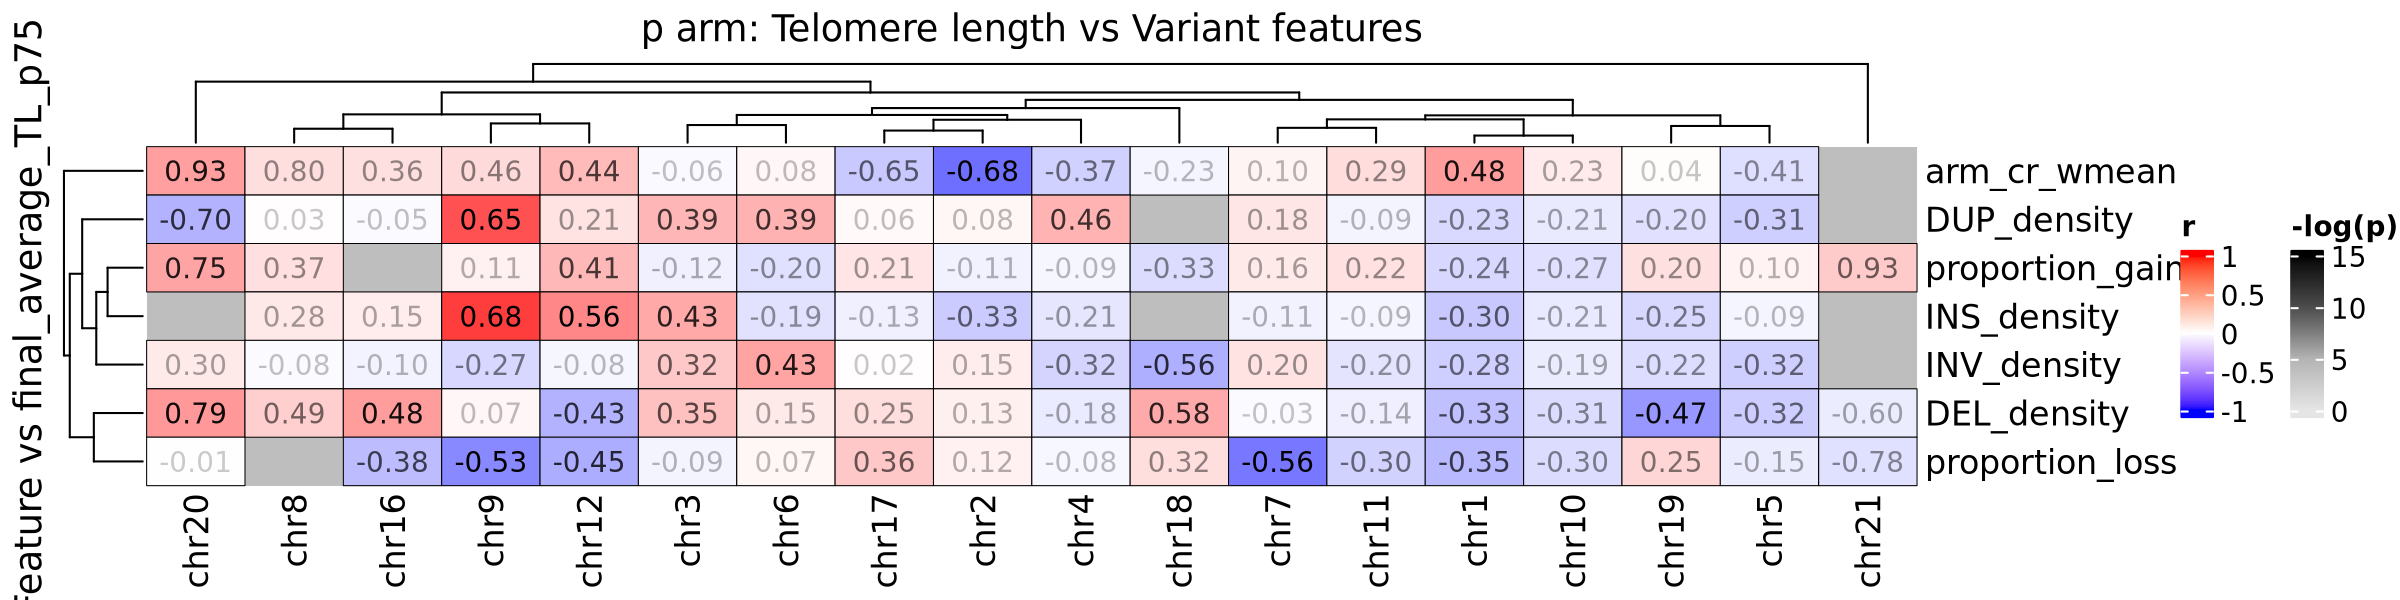

In [255]:
#pdf(file = "fig_03_p_arm_heatmap.pdf", width =12, height = 3)
options(repr.plot.width = 12, repr.plot.height = 3, repr.plot.res = 200)
# Draw the heatmap with the additional legend
draw(heatmap_p, annotation_legend_list = list(p_legend))
#dev.off()

In [256]:
# Load required libraries
library(ComplexHeatmap)
library(circlize)

# Set plot dimensions to adjust tile sizes (increase for larger tiles)
options(repr.plot.width = 10, repr.plot.height = 10)  # Adjust these values as needed

# Create the heatmap for q arm
heatmap_q = Heatmap(
  corr_matrix_q,  # Correlation matrix for q arm
  name = "Correlation",
  col = colorRamp2(c(-1, 0, 1), c("blue", "white", "red")),  # Same color scale as p arm
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  column_title = "q arm: Telomere length vs Variant features",  # Updated title for q arm
  row_title = "Feature vs final_average_TL_p75",
  heatmap_legend_param = list(title = "r"),
  cell_fun = function(j, i, x, y, width, height, fill) {
    if (!is.na(corr_matrix_q[i, j]) && !is.na(pval_matrix_q[i, j]) && pval_matrix_q[i, j] > 0) {
      # Compute text color opacity based on -log(p-value)
      log_p = -log(pval_matrix_q[i, j])
      alpha = min(log_p / 3, 1)  # Cap at 3 (p=0.001) and scale to [0,1]
      text_alpha = 0.2 + 0.8 * alpha  # Text opacity from 0.2 (faint) to 1 (fully opaque)
      text_col = rgb(0, 0, 0, text_alpha)
      # Draw cell background using precomputed color
      grid.rect(x = x, y = y, width = width, height = height,
                gp = gpar(col = NA, fill = color_matrix_q[i, j]))  # Use q arm color matrix
      # Add correlation value with adjusted text color intensity
      grid.text(sprintf("%.2f", corr_matrix_q[i, j]), x, y,
                gp = gpar(fontsize = 10, col = text_col))
      # Add cell border
      grid.rect(x = x, y = y, width = width, height = height,
                gp = gpar(col = "black", fill = NA, lwd = 0.5))
    }
  }
)

# Create a legend for -log10(p-value), identical to p arm
q_legend = Legend(
  col_fun = colorRamp2(c(0, 5, 10, 15), c("grey90", "grey70", "grey30", "black")),
  title = "-log(p)",
  at = c(0, 5, 10, 15),  # Key points corresponding to p=1, 0.1, 0.01, 0.001
  direction = "vertical"
)


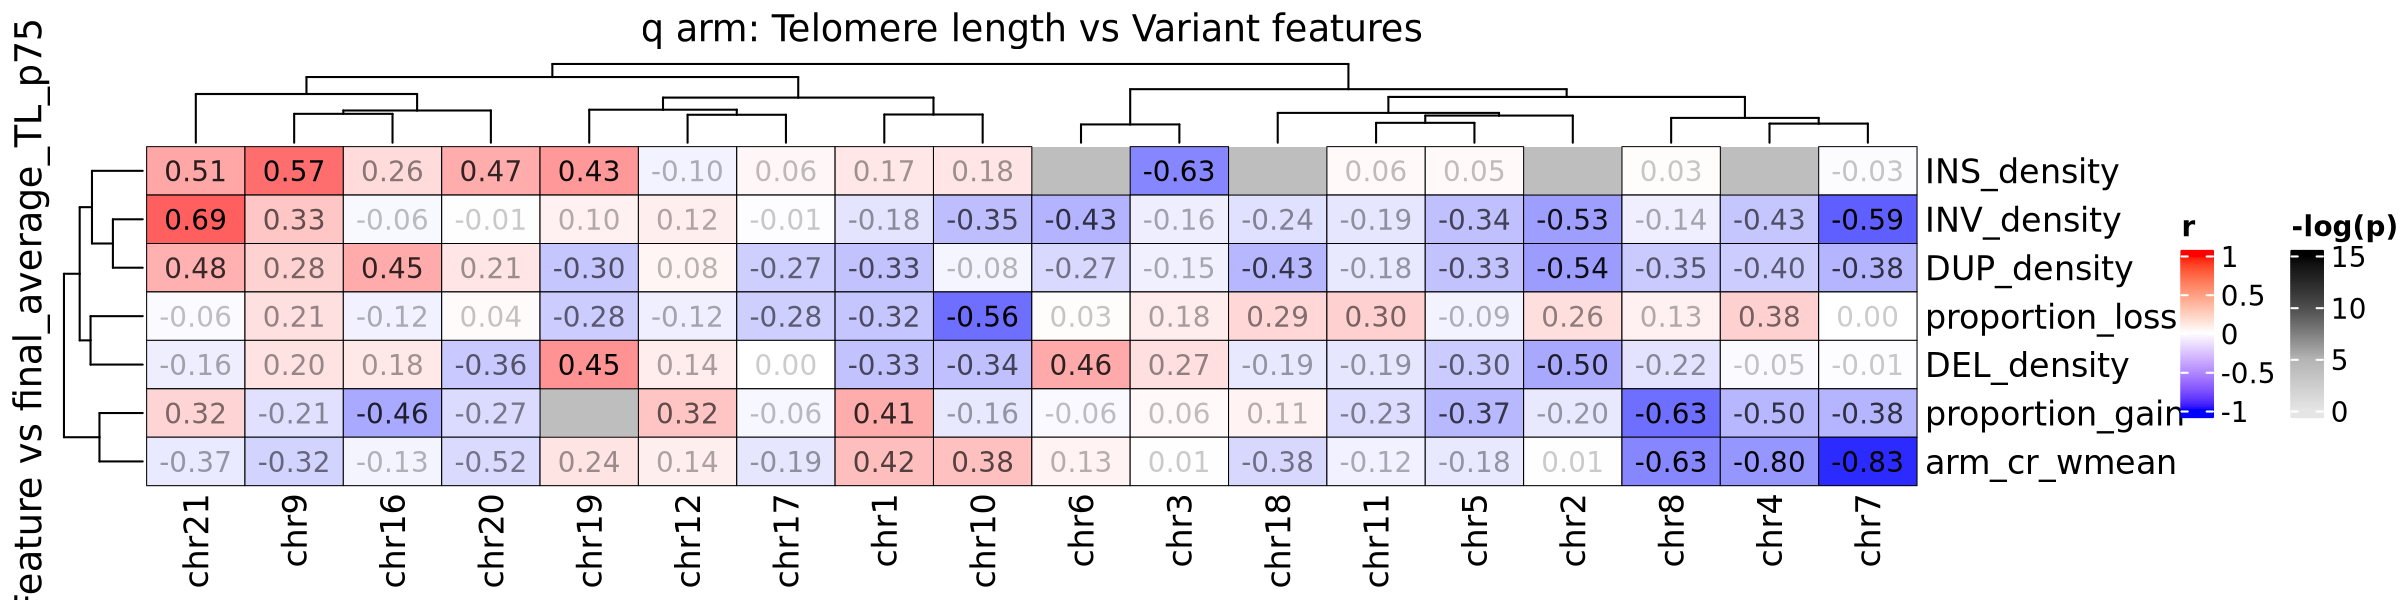

In [257]:
#pdf(file = "fig_03_q_arm_heatmap.pdf", width =12, height = 3)
options(repr.plot.width = 12, repr.plot.height = 3, repr.plot.res = 200)
draw(heatmap_q, annotation_legend_list = list(q_legend))
#dev.off()

In [265]:


    # Define your variables
varnames <- c("SV_density", "proportion_gain", "proportion_loss", "arm_cr_wmean")

# Store plots in a list
plot_list <- list()

# Function to assign stars based on p-value
get_significance_stars <- function(p) {
  if (p < 0.001) return("***")  # Highly significant
  else if (p < 0.01) return("**")  # Significant
  else if (p < 0.05) return("*")  # Marginally significant
  else return("ns")  # Not significant
}

# Loop over each unique pair of variables
for (i in 1:(length(varnames) - 1)) {
  for (j in (i + 1):length(varnames)) {
    
    # Subset data and remove NAs
    temp_data <- final_df[, c(varnames[i], varnames[j]), drop = FALSE]
    temp_data <- na.omit(temp_data)
    
    # Ensure enough data points
    if (nrow(temp_data) > 2) {
        # Compute correlation and p-value
      cor_test <- cor.test(temp_data[[varnames[i]]], temp_data[[varnames[j]]], method = "pearson")
      corr_value <- round(cor_test$estimate, 3)
      p_value <- signif(cor_test$p.value, 3)
      
      # Get significance stars
      significance <- get_significance_stars(p_value)
        
              options(repr.plot.width = 10, repr.plot.height = 3, repr.plot.res = 200)

      # Create scatter plot
      p <- ggplot(temp_data, aes_string(x = varnames[i], y = varnames[j])) +
        geom_point(color = "blue") + 
        geom_smooth(method = "lm", se = TRUE, color = "red") +
        labs(title = paste(varnames[i], "vs.", varnames[j]),
             x = varnames[i], y = varnames[j]) +
        annotate("text", x = min(temp_data[[varnames[i]]]), y = max(temp_data[[varnames[j]]]), 
                 label = paste("r =", corr_value, "\nP =", p_value, significance), 
                 hjust = 0, vjust = 1, color = "black", size = 3.5) +
        theme_minimal()
      
      # Store plot in list
      plot_list[[length(plot_list) + 1]] <- p
    } else {
      message(paste("Not enough data to plot", varnames[i], "vs.", varnames[j]))
    }
  }
}

# Arrange plots in a grid (3 plots per row)
ggarrange(plotlist = plot_list, ncol = 3, nrow = ceiling(length(plot_list) / 8))


ERROR: [1m[33mError[39m in `final_df[, c(varnames[i], varnames[j]), drop = FALSE]`:[22m
[33m![39m Can't subset columns that don't exist.
[31m✖[39m Column `SV_density` doesn't exist.


`geom_smooth()` using formula = 'y ~ x'


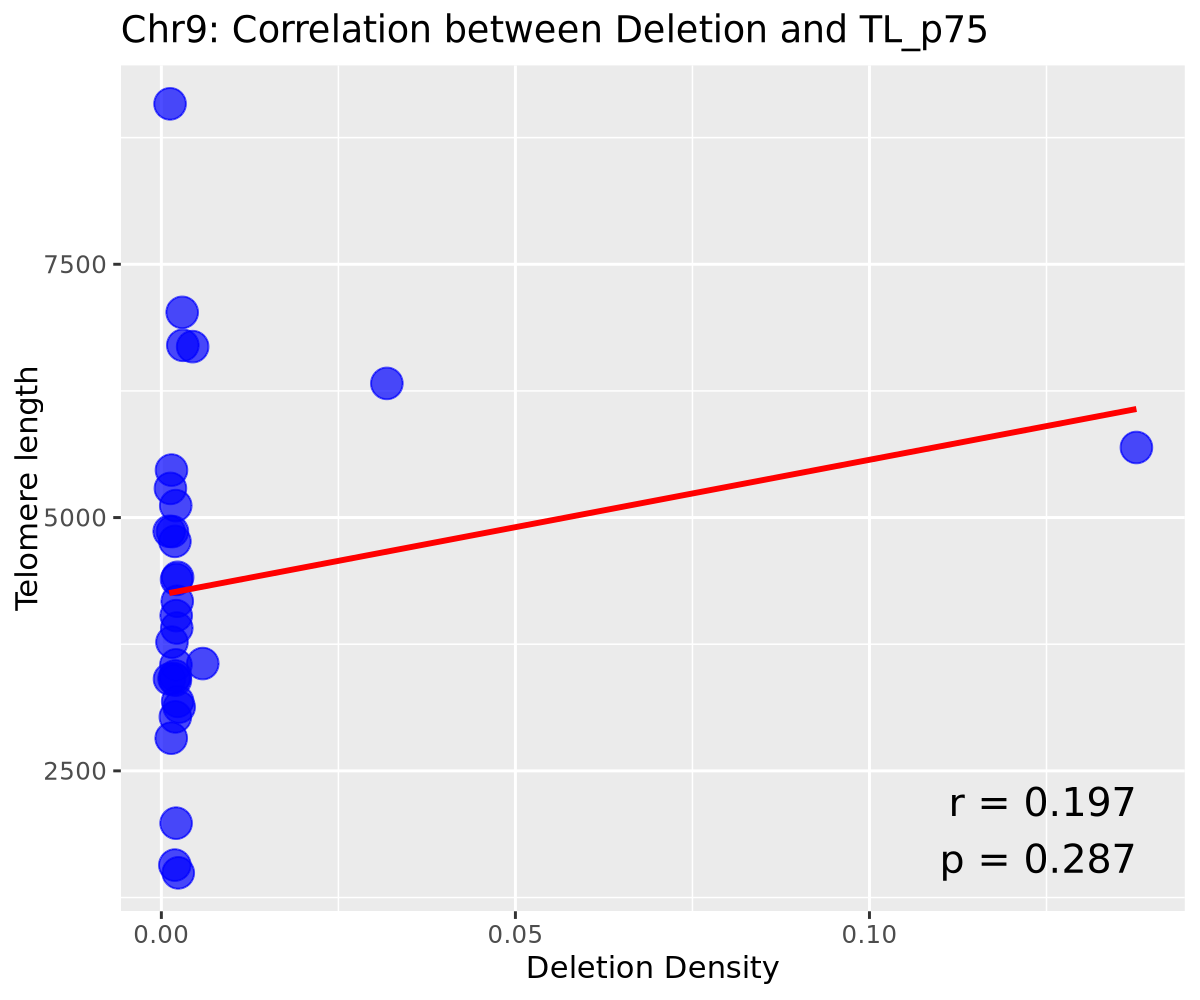

In [266]:
# Filter data for chromosome 9 p arm
#df_p_chr9 <- final_df[final_df$chr == "chr9" & final_df$arm == "p", ]
df_p_chr9 <- final_df[final_df$chr == "chr9", ]

# Perform Pearson correlation test
cor_test <- cor.test(df_p_chr9$DEL_density, df_p_chr9$final_average_TL_p75, method = "pearson")

# Extract correlation coefficient and p-value
cor_value <- round(cor_test$estimate, 3)
p_value <- signif(cor_test$p.value, 3)



#pdf(file = "chr20_deletion_sv_corr.pdf", width = 4, height =6)
options(repr.plot.width = 6, repr.plot.height = 5, repr.plot.res = 200)

# Create scatter plot
ggplot(df_p_chr9, aes(x = DEL_density, y = final_average_TL_p75)) +
  geom_point(color = "blue", size = 5, alpha = 0.7) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  labs(
    title = "Chr9: Correlation between Deletion and TL_p75",
    x = "Deletion Density",
    y = "Telomere length"
  ) +
  annotate("text", x = max(df_p_chr9$DEL_density, na.rm = TRUE), 
           y = min(df_p_chr9$final_average_TL_p75, na.rm = TRUE), 
           label = paste0("r = ", cor_value, "\n p = ", p_value),
           hjust = 1, vjust = 0, size = 5, color = "black")
#dev.off()

`geom_smooth()` using formula = 'y ~ x'


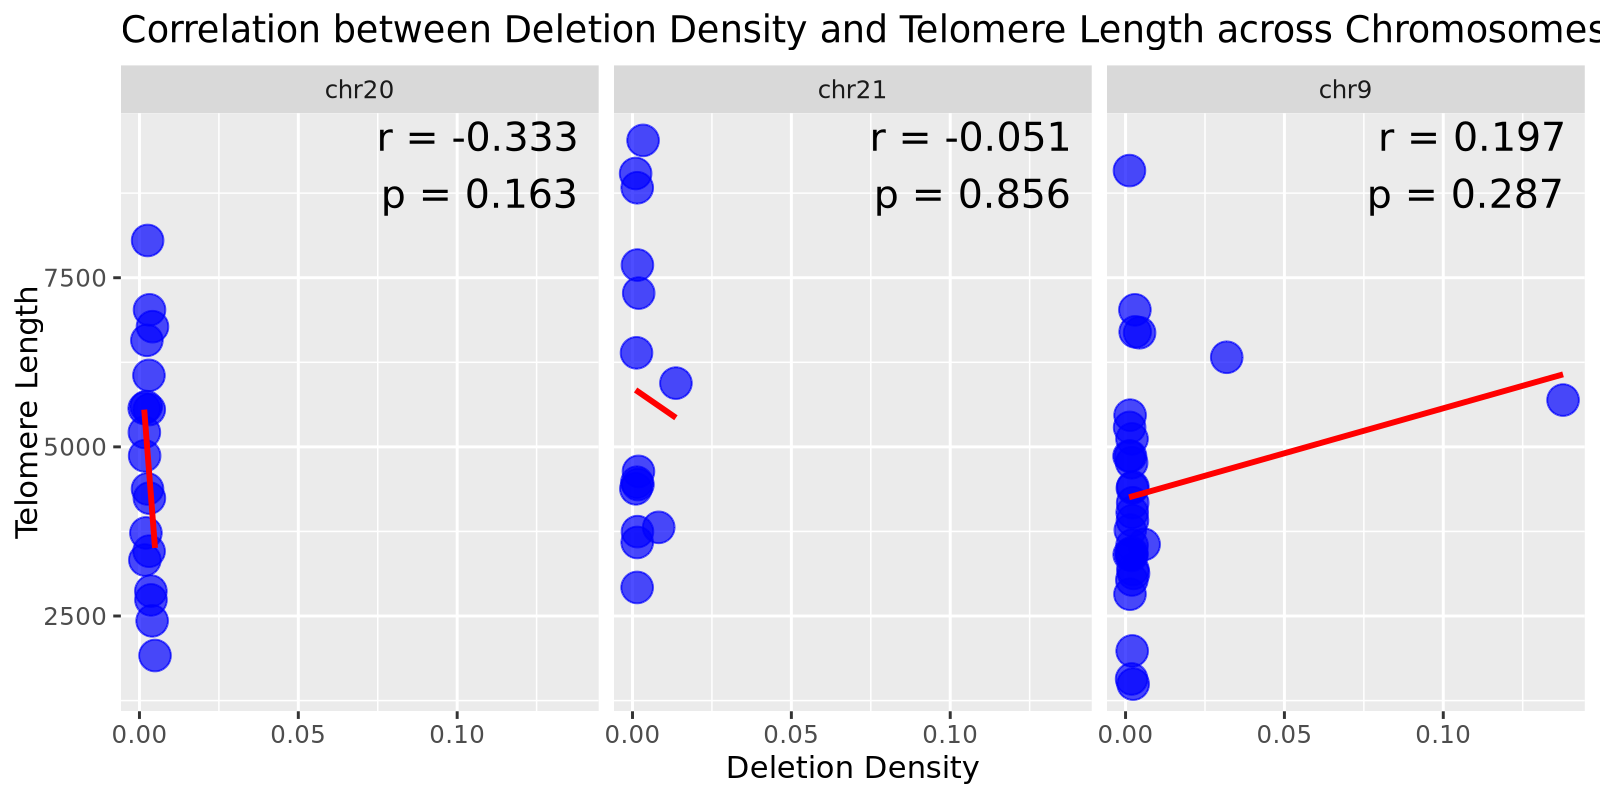

In [267]:
library(ggplot2)
library(dplyr)

# Filter data for chromosomes chr9, chr20, and chr21
df_multi <- final_df %>% 
  filter(chr %in% c("chr9", "chr20", "chr21"))

# Compute Pearson correlation for each chromosome
cor_data <- df_multi %>%
  group_by(chr) %>%
  summarise(
    cor_value = round(cor(DEL_density, final_average_TL_p75, method = "pearson"), 3),
    p_value = signif(cor.test(DEL_density, final_average_TL_p75)$p.value, 3)
  )

# Open PDF device with adjusted dimensions (wider for three panels)
#pdf(file = "chr_deletion_sv_corr.pdf", width = 8, height = 4)
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

# Create scatter plot with three panels using facet_wrap
ggplot(df_multi, aes(x = DEL_density, y = final_average_TL_p75)) +
  geom_point(color = "blue", size = 5, alpha = 0.7) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  facet_wrap(~ chr, nrow = 1) +
  labs(
    title = "Correlation between Deletion Density and Telomere Length across Chromosomes",
    x = "Deletion Density",
    y = "Telomere Length"
  ) +
  # Annotate each panel with its correlation coefficient and p-value
  geom_text(
    data = cor_data,
    aes(x = Inf, y = Inf, 
        label = paste0("r = ", cor_value, "\n p = ", p_value)),
    hjust = 1.1, vjust = 1.1, size = 5, color = "black"
  )

#dev.off()


`geom_smooth()` using formula = 'y ~ x'


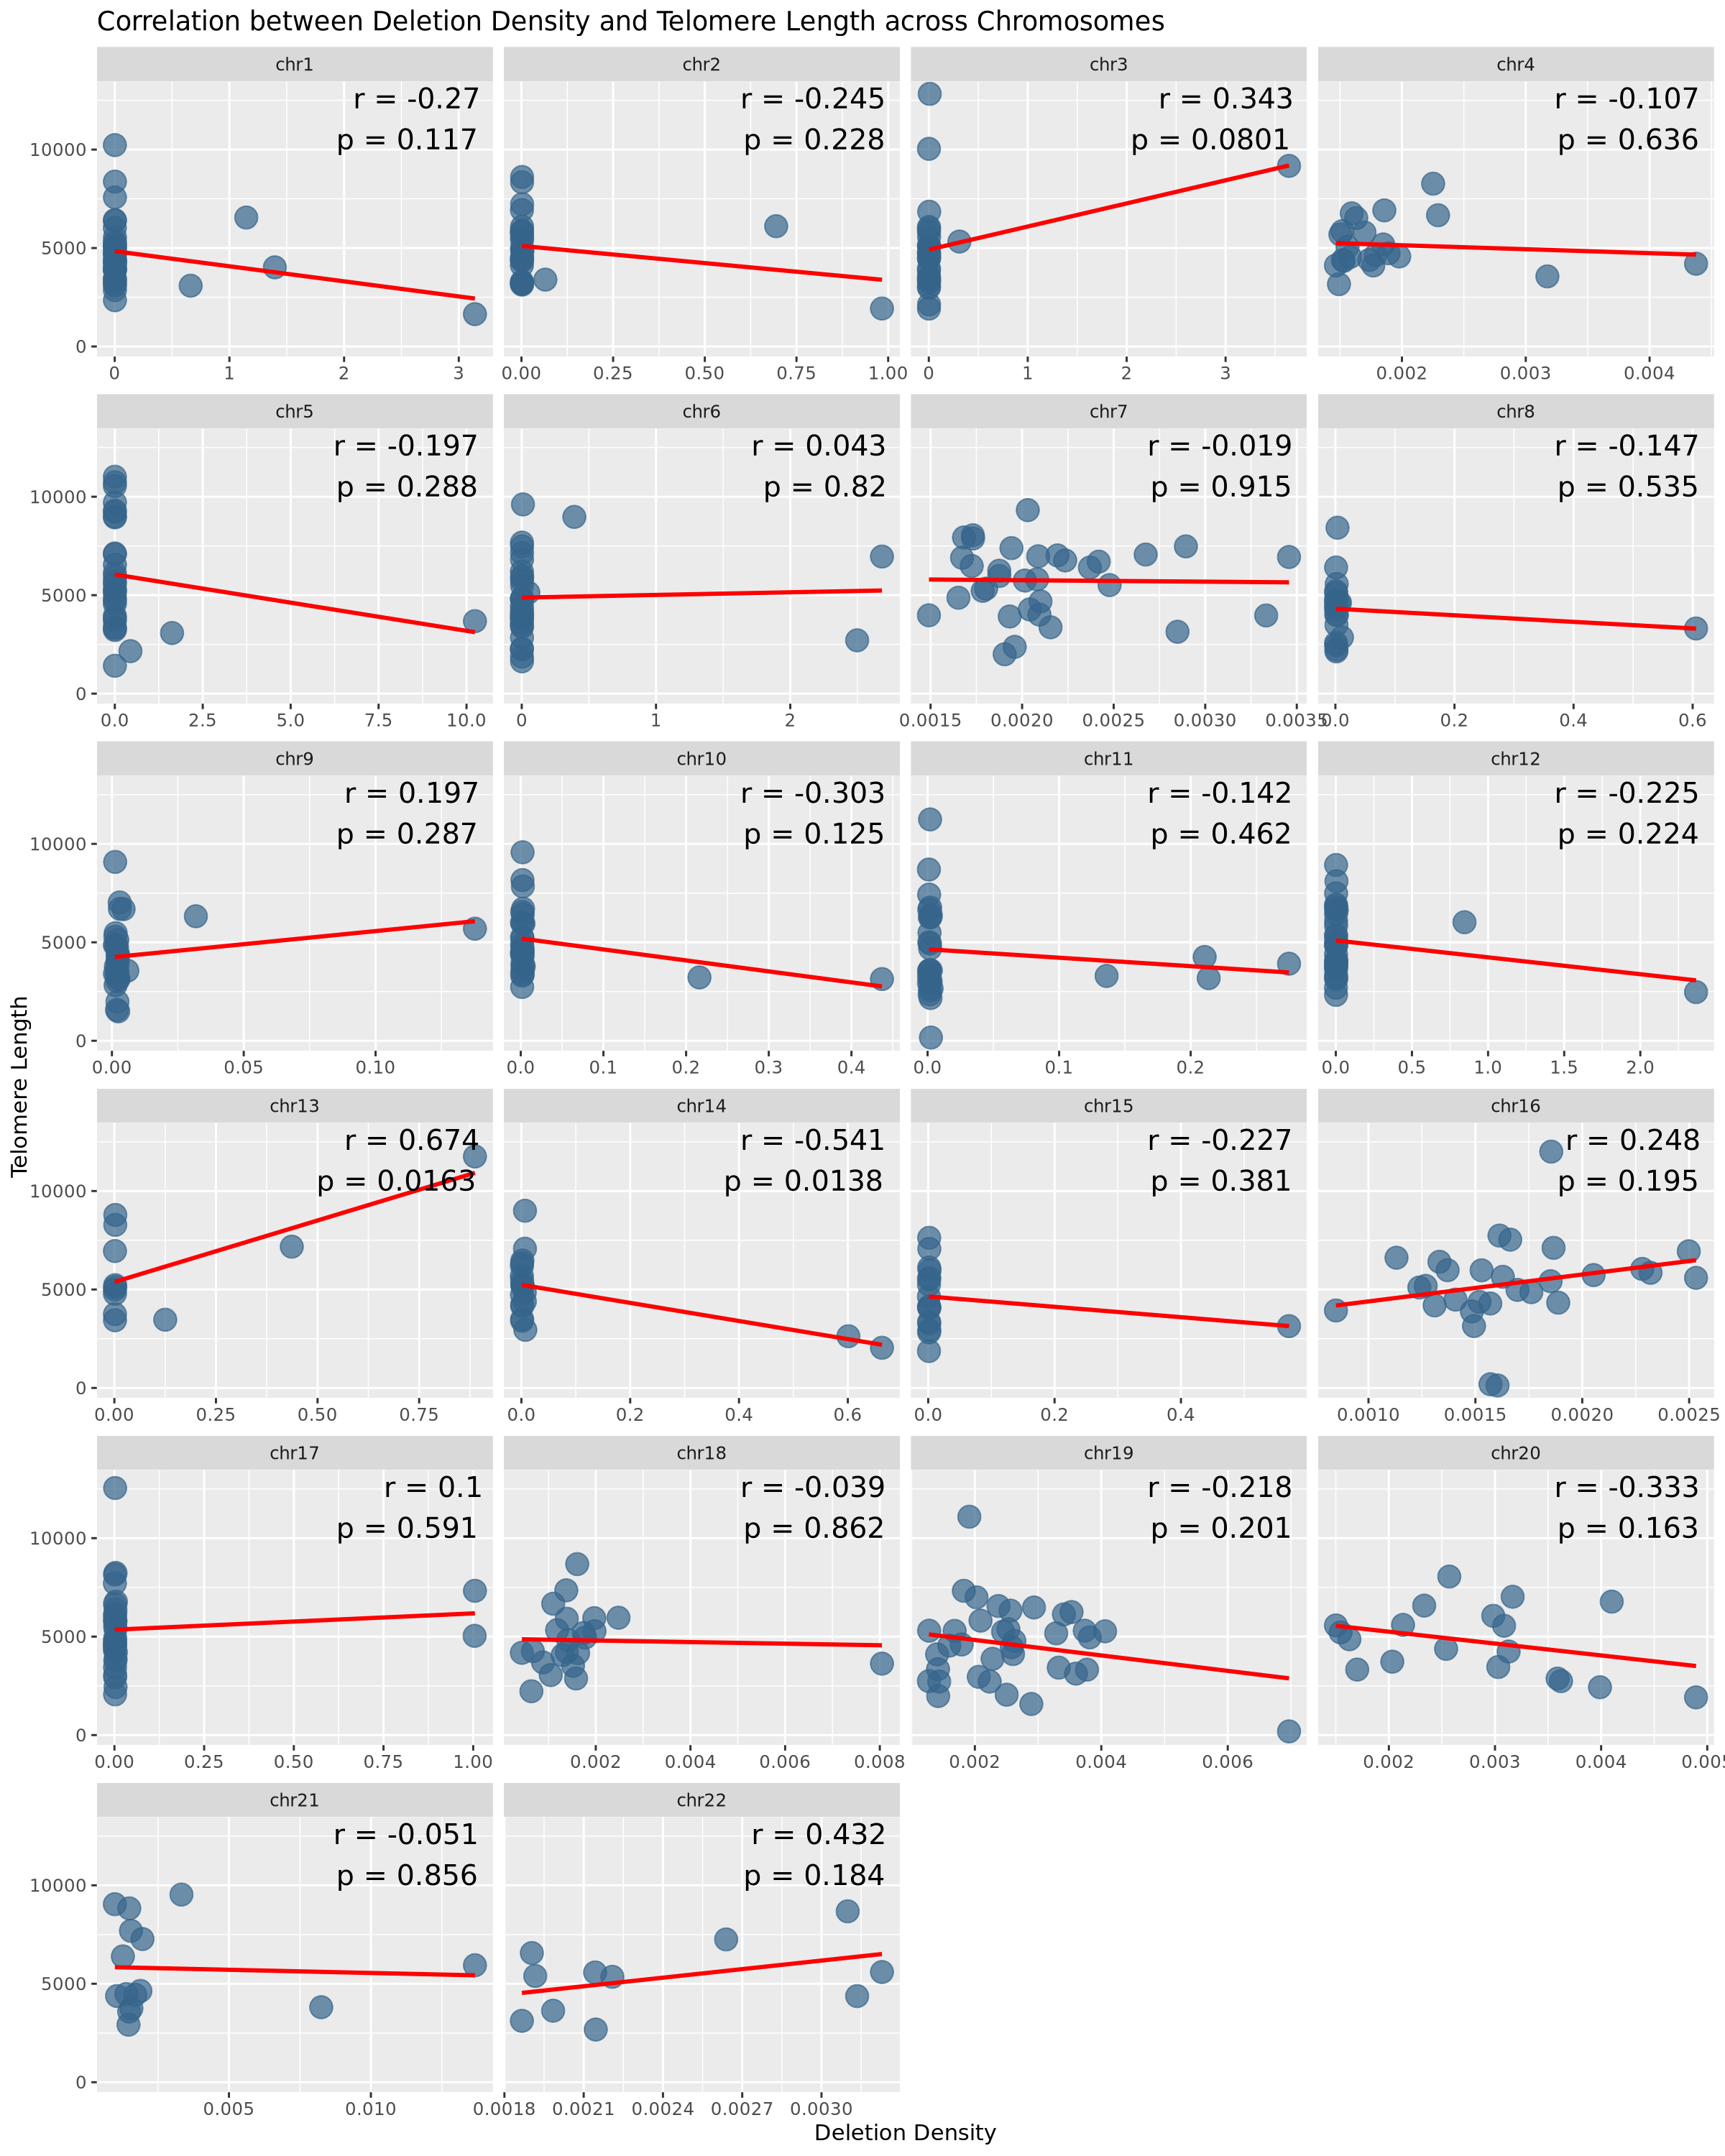

In [268]:
library(ggplot2)
library(dplyr)

# Use the full dataset without filtering for specific chromosomes
df_multi <- final_df

# Set 'chr' as a factor with levels in the order chr1 to chr22, chrX
df_multi$chr <- factor(df_multi$chr, levels = paste0("chr", c(1:22, "X")))

# Compute Pearson correlation and p-value for each chromosome
cor_data <- df_multi %>%
  group_by(chr) %>%
  summarise(
    cor_value = round(cor(DEL_density, final_average_TL_p75, method = "pearson"), 3),
    p_value = signif(cor.test(DEL_density, final_average_TL_p75)$p.value, 3)
  )

# Set plot dimensions to accommodate multiple rows (4 facets per row)
options(repr.plot.width = 12, repr.plot.height = 15, repr.plot.res = 200)

#pdf(file = "All_chrs_deletion_sv_corr_V2.pdf", width = 12, height = 15)
# Create scatter plot with facets for all chromosomes, 4 per row
ggplot(df_multi, aes(x = DEL_density, y = final_average_TL_p75)) +
  geom_point(color = "steelblue4", size = 5, alpha = 0.7) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  facet_wrap(~ chr, ncol = 4, scales = "free_x") +
  labs(
    title = "Correlation between Deletion Density and Telomere Length across Chromosomes",
    x = "Deletion Density",
    y = "Telomere Length"
  ) +
  # Annotate each facet with its correlation coefficient and p-value
  geom_text(
    data = cor_data,
    aes(x = Inf, y = Inf, 
        label = paste0("r = ", cor_value, "\n p = ", p_value)),
    hjust = 1.1, vjust = 1.1, size = 5, color = "black"
  )
#dev.off()

In [269]:
head(df_multi, n = 2)


SampleID,chr,arm,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,INS_density,DEL_density,DUP_density,INV_density,BND_density,chrom_num
<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr10,q,0,0.1978753,2732.75,0,5,0.9870386,0,0.001693335,0.0002515489,0,0,10
2436A,chr11,p,0,0.0000000,6766.00,0,6,1.0067300,0,0.001977104,0.0000000000,0,0,11


`geom_smooth()` using formula = 'y ~ x'


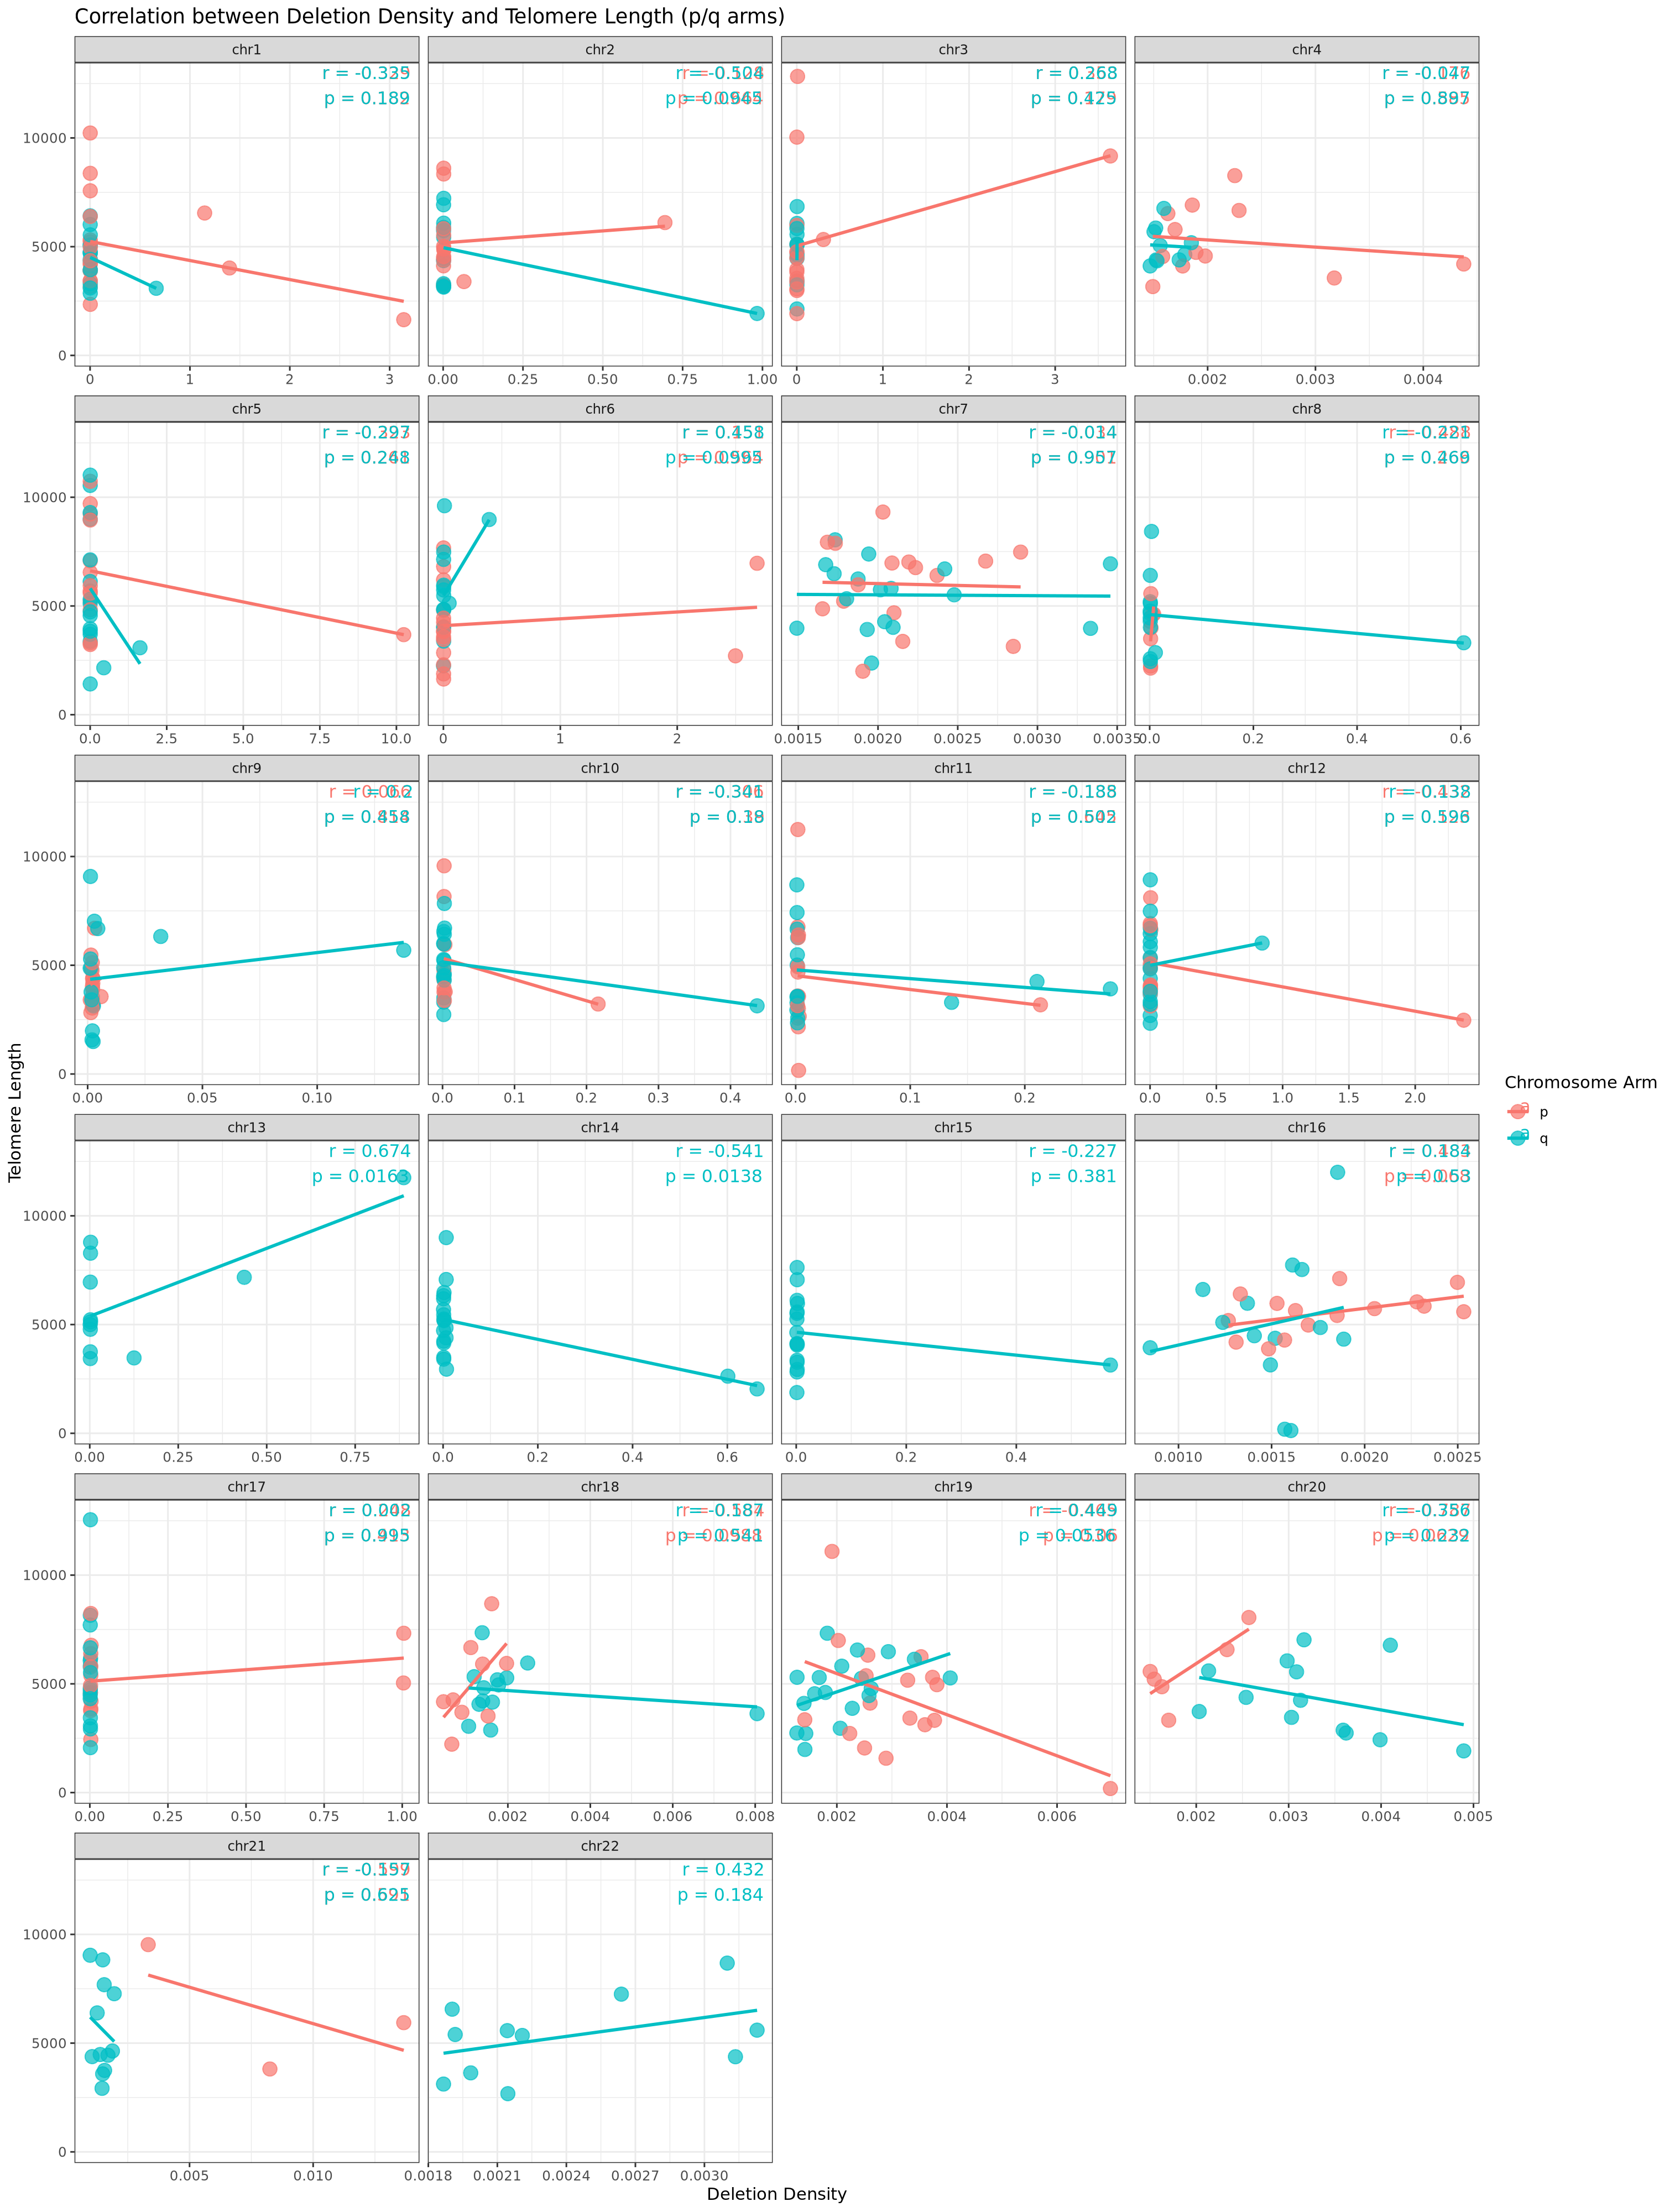

In [270]:
library(ggplot2)
library(dplyr)

df_multi$chr <- factor(df_multi$chr, levels = paste0("chr", c(1:22, "X")))

# Compute correlation stats for each chr + arm
cor_data <- df_multi %>%
  group_by(chr, arm) %>%
  summarise(
    cor_value = round(cor(DEL_density, final_average_TL_p75, method = "pearson"), 3),
    p_value = signif(cor.test(DEL_density, final_average_TL_p75)$p.value, 3),
    .groups = "drop"
  )

options(repr.plot.width = 15, repr.plot.height = 20, repr.plot.res = 200)
#pdf(file = "All_chrs_deletion_sv_corr_V3.pdf", width = 12, height = 15)

ggplot(df_multi, aes(x = DEL_density, y = final_average_TL_p75, color = arm)) +
  geom_point(size = 4, alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE) +
  facet_wrap(~ chr, ncol = 4, scales = "free_x") +
  labs(
    title = "Correlation between Deletion Density and Telomere Length (p/q arms)",
    x = "Deletion Density",
    y = "Telomere Length",
    color = "Chromosome Arm"
  ) +
  geom_text(
    data = cor_data,
    aes(x = Inf, y = Inf, 
        label = paste0("r = ", cor_value, "\n p = ", p_value),
        color = arm),
    hjust = 1.1, vjust = 1.1, size = 4, inherit.aes = FALSE
  ) +
  theme_bw()
#dev.off()

In [271]:
head(corr_matrix_p)

,chr1,chr2,chr3,chr4,chr5,chr6,chr7,chr8,chr9,chr10,chr11,chr12,chr16,chr17,chr18,chr19,chr20,chr21
proportion_gain,-0.2401687,-0.10926631,-0.11853593,-0.09010951,0.10254104,-0.20282291,0.15626176,0.36904365,0.11372559,-0.2707263,0.22122358,0.4075565,NA,0.20680129,-0.3293098,0.20230388,0.749909638,0.9295450
proportion_loss,-0.3534555,0.11878517,-0.08752877,-0.08047472,-0.15342410,0.07368080,-0.55692741,NA,-0.53484363,-0.3045381,-0.30148049,-0.4489629,-0.37870071,0.36122379,0.3168385,0.25090218,-0.009761282,-0.7840836
arm_cr_wmean,0.4790547,-0.68375873,-0.05679234,-0.37152933,-0.41113111,0.07809592,0.10129968,0.79905073,0.45699089,0.2329334,0.28622329,0.4398940,0.35707701,-0.65208891,-0.2278119,0.03574548,0.925501165,NA
INS_density,-0.3005096,-0.33263535,0.43000357,-0.21311896,-0.08513417,-0.19213766,-0.10562308,0.28233200,0.68099625,-0.2147304,-0.08900921,0.5574041,0.14570969,-0.12991834,NA,-0.24503960,NA,NA
DEL_density,-0.3294067,0.12765477,0.35336799,-0.17553143,-0.32259225,0.15058547,-0.03385042,0.48831767,0.06639281,-0.3057871,-0.13518752,-0.4323248,0.48325604,0.24833548,0.5838967,-0.46506308,0.787486747,-0.5989097
DUP_density,-0.2311627,0.08183765,0.38621341,0.46483508,-0.31439395,0.38793833,0.17714544,0.02818283,0.64796961,-0.2078215,-0.09345504,0.2102346,-0.04503392,0.05863819,NA,-0.19867757,-0.695890976,NA


In [38]:
head(pval_matrix_p)

,chr1,chr2,chr3,chr4,chr5,chr6,chr7,chr8,chr9,chr10,chr11,chr12,chr16,chr17,chr18,chr19,chr20,chr21
proportion_gain,3.370810e-01,7.100148e-01,6.619450e-01,7.806294e-01,7.272217e-01,4.349614e-01,5.633224e-01,0.4152688,0.686536732,0.4493157609,0.4472174,0.148048178,NA,0.4978421994,0.386842211,0.43616277,0.08599681,0.24039999
proportion_loss,1.501895e-01,6.858799e-01,7.471999e-01,8.036569e-01,6.005174e-01,7.786832e-01,2.503024e-02,NA,0.039950681,0.3922443333,0.2948726,0.107320197,0.163935057,0.2252597412,0.406128332,0.33137053,0.98535854,0.42626668
arm_cr_wmean,1.806339e-01,7.160913e-02,5.781191e-01,7.415860e-01,6.168363e-01,5.618413e-01,7.552930e-01,0.7433075,0.165780318,0.9910760782,0.2092269,0.028745693,0.900282830,0.1515645364,0.310504258,0.96025520,0.02411315,0.05399111
INS_density,2.256358e-01,2.452200e-01,9.642657e-02,5.060189e-01,7.722989e-01,4.600357e-01,6.970448e-01,0.5395706,0.005190558,0.5513432430,0.7622008,0.038367529,0.604351740,0.6722740904,NA,0.34316539,NA,NA
DEL_density,6.470273e-06,3.611737e-05,4.286676e-06,6.604062e-05,3.473386e-05,9.816398e-06,2.572757e-08,0.0325445,0.504253446,0.0002106283,0.0671614,0.004995405,0.001968228,0.0004157752,0.007387509,0.04011521,0.02750665,0.16011412
DUP_density,1.722674e-01,6.290210e-01,1.351068e-01,3.561983e-01,1.144848e-01,7.623107e-02,5.170389e-01,0.5731764,0.237000068,0.4854648944,0.2721110,0.218828529,0.482668473,0.9234587877,NA,0.30932193,0.12466110,NA



Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt


The following object is masked from ‘package:tidyr’:

    smiths


Warning message:
“Removed 8 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


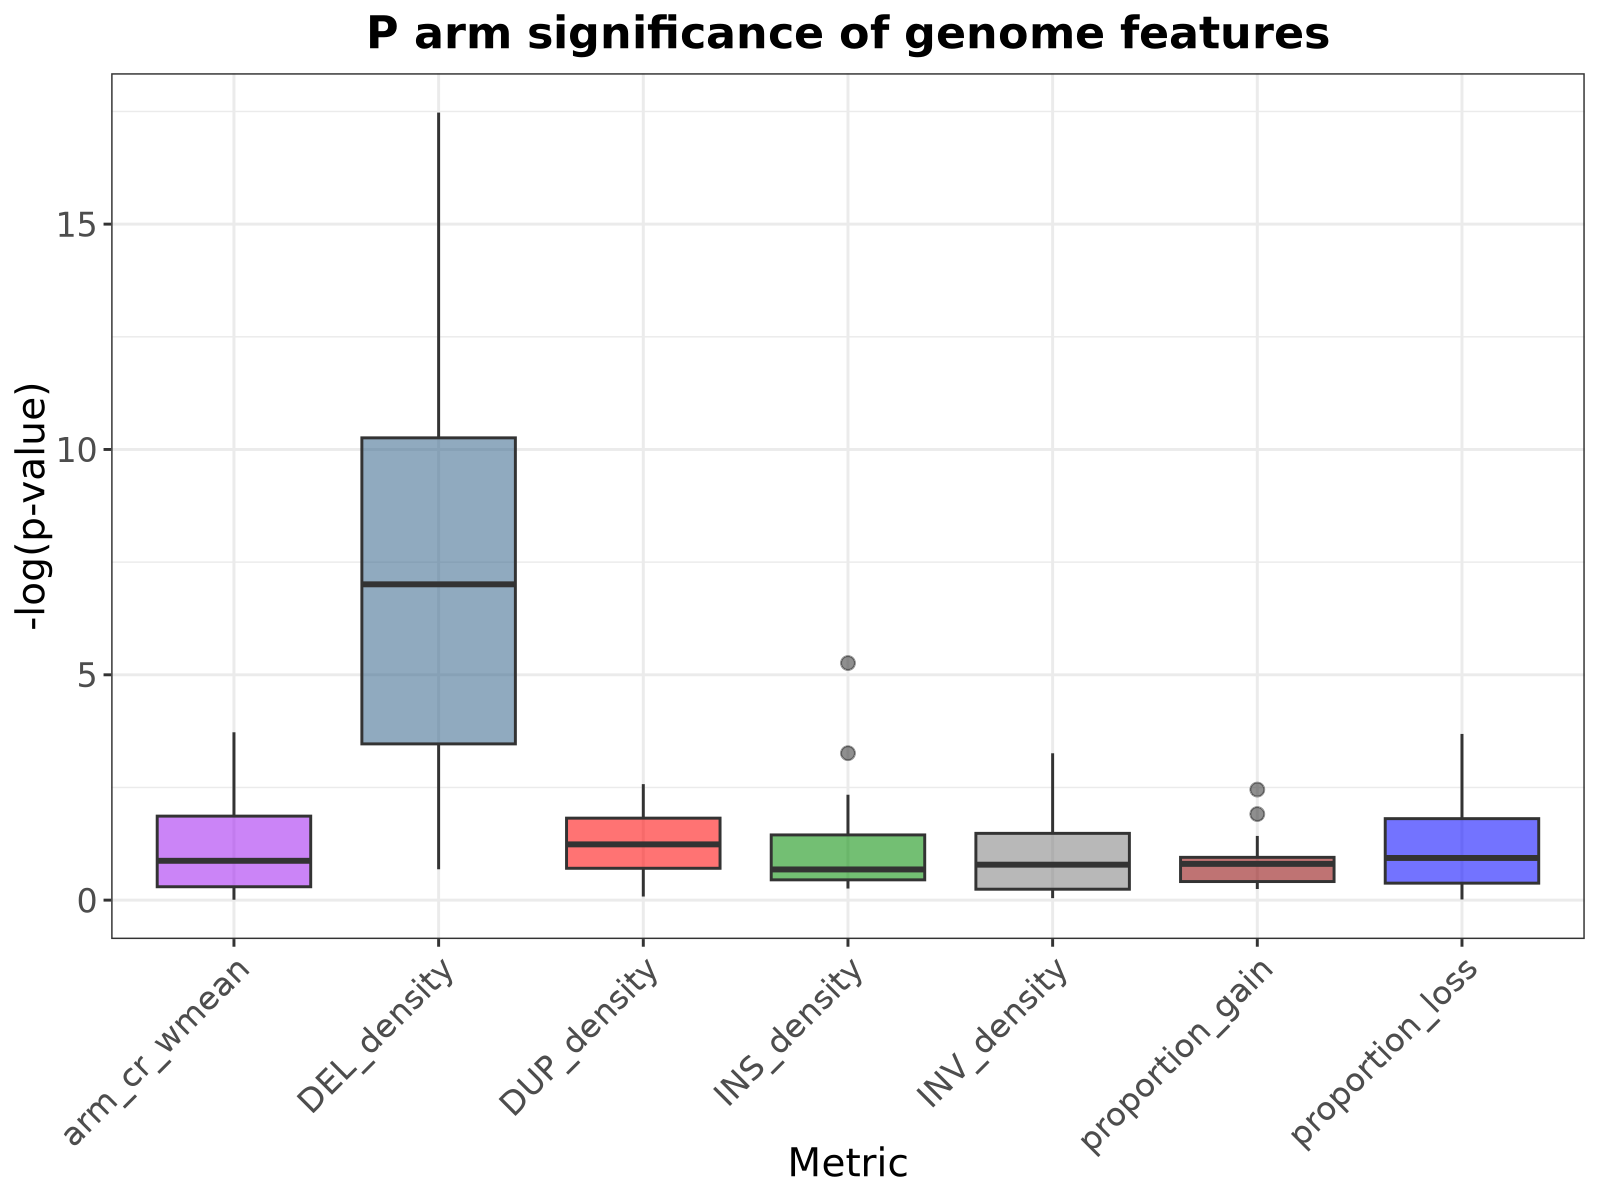

In [39]:
library(ggplot2)
library(reshape2)

# Compute -log10 of the p-values
log_pvals <- -log(pval_matrix_p)

# Convert the matrix to a data frame and add a column for the metric names (row names)
df <- as.data.frame(log_pvals)
df$Metric <- rownames(log_pvals)

# Reshape the data frame to long format; each row will have Metric, Chromosome, and value
df_long <- melt(df, id.vars = "Metric", variable.name = "Chromosome", value.name = "NegLog10P")

metric_colors <- c(
  "proportion_gain" = "darkred",
  "proportion_loss" = "blue",
  "arm_cr_wmean" = "purple",
  "INS_density" = "green4",
  "DEL_density" = "steelblue4",
  "DUP_density" = "red"
)

options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 200)
#pdf(file = "parm_boxplot_neg_log_cor_pvalues.pdf", width = 8, height = 4)
# Create the boxplot with customized aesthetics
ggplot(df_long, aes(x = Metric, y = NegLog10P, fill = Metric, alpha = 0.7)) +
  geom_boxplot(outlier.size = 2) +
  labs(
    title = "P arm significance of genome features",
    x = "Metric",
    y = "-log(p-value)"
  ) +
  scale_fill_manual(values = metric_colors) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.position = "none"
  )
#dev.off()

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


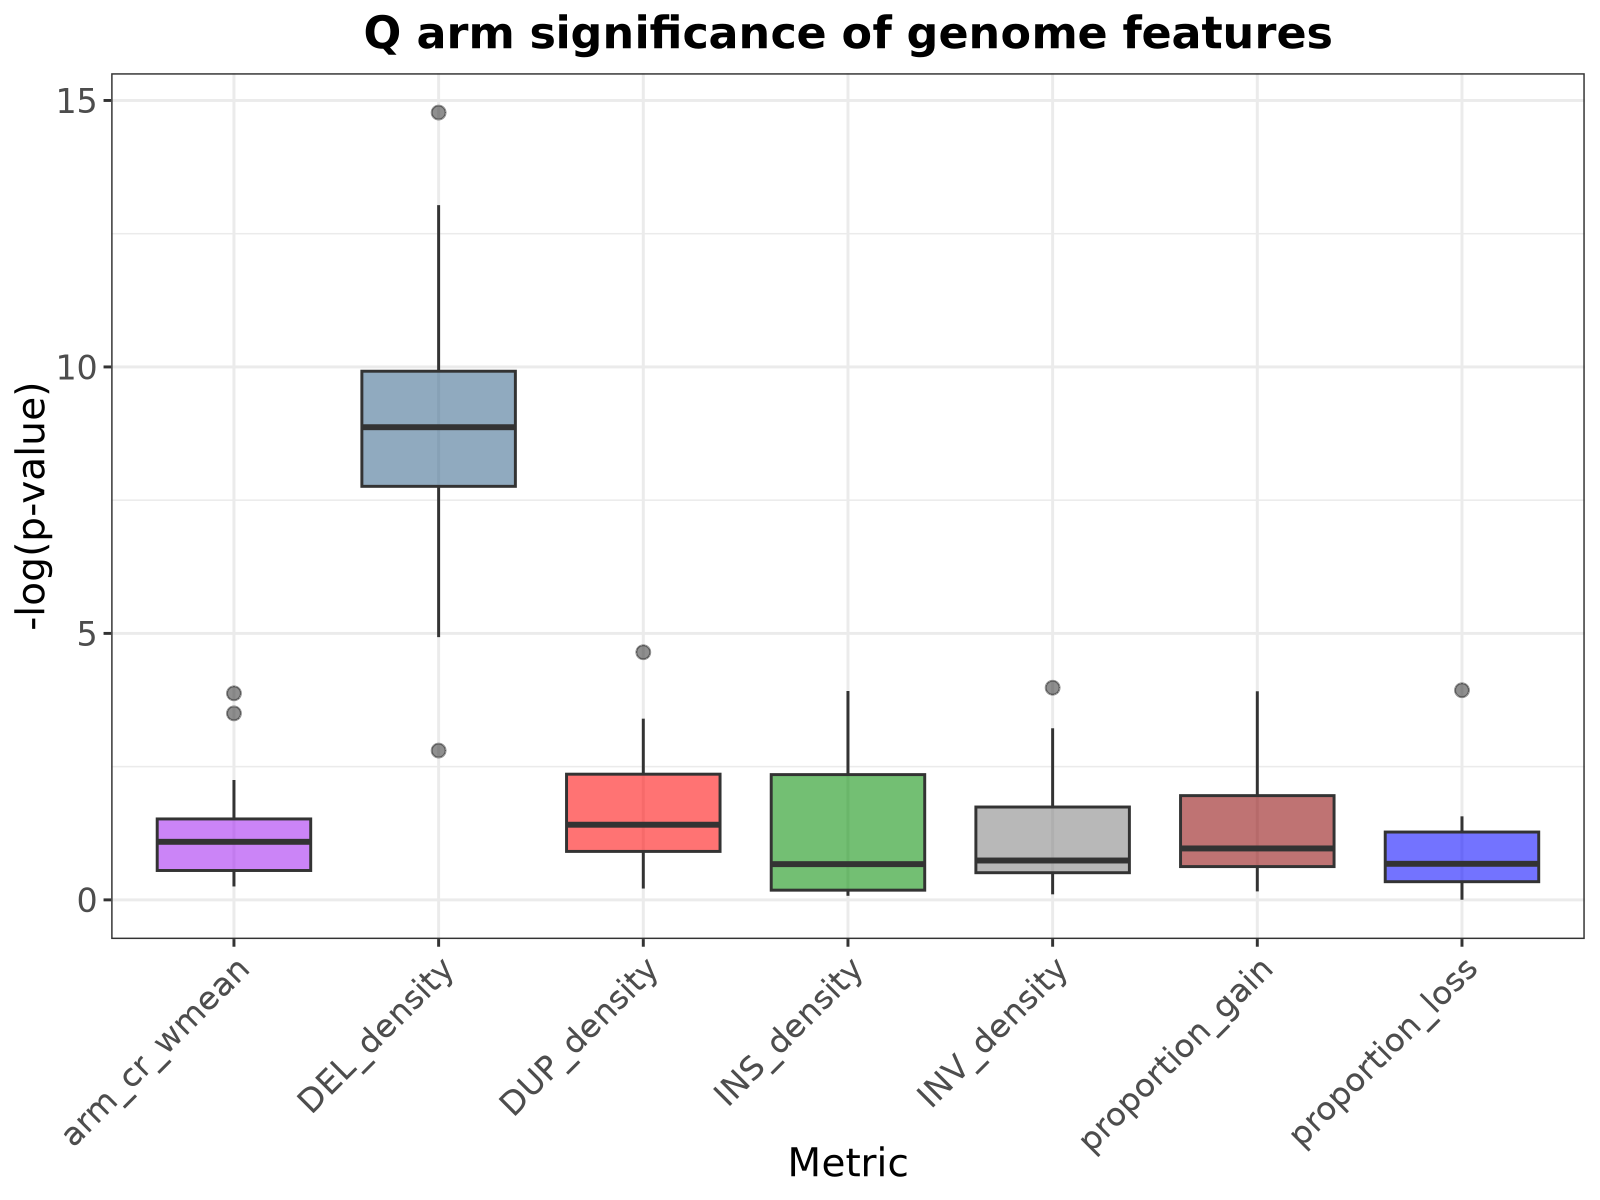

In [40]:
library(ggplot2)
library(reshape2)

# Compute -log10 of the p-values
log_pvals <- -log(pval_matrix_q)

# Convert the matrix to a data frame and add a column for the metric names (row names)
df <- as.data.frame(log_pvals)
df$Metric <- rownames(log_pvals)

# Reshape the data frame to long format; each row will have Metric, Chromosome, and value
df_long <- melt(df, id.vars = "Metric", variable.name = "Chromosome", value.name = "NegLog10P")

#DEL density blue dup red inv orange ins green ao da cnvs losss and gain da red ao blue bal shade show ka
# Define the custom colors for each metric
metric_colors <- c(
  "proportion_gain" = "darkred",
  "proportion_loss" = "blue",
  "arm_cr_wmean" = "purple",
  "INS_density" = "green4",
  "DEL_density" = "steelblue4",
  "DUP_density" = "red"
)

options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 200)

#pdf(file = "qarm_boxplot_neg_log_cor_pvalues.pdf", width = 8, height = 4)
# Create the boxplot with customized aesthetics
ggplot(df_long, aes(x = Metric, y = NegLog10P, fill = Metric, alpha = 0.7)) +
  geom_boxplot(outlier.size = 2) +
  labs(
    title = "Q arm significance of genome features",
    x = "Metric",
    y = "-log(p-value)"
  ) +
  scale_fill_manual(values = metric_colors) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.position = "none"
  )
#dev.off()

In [272]:
head(final_df)

SampleID,chr,arm,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,INS_density,DEL_density,DUP_density,INV_density,BND_density,chrom_num
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr10,q,0.00000000,0.1978753,2732.75,0,5,0.9870386,0,0.001693335,0.0002515489,0.0000000,0,10
2436A,chr11,p,0.00000000,0.0000000,6766.00,0,6,1.0067300,0,0.001977104,0.0000000000,0.0000000,0,11
2436A,chr12,p,0.00000000,0.0000000,5319.40,0,2,1.0909572,0,0.001893591,0.0000000000,2.7773186,0,12
2436A,chr12,q,0.00000000,0.0000000,6085.00,0,10,1.0029376,0,0.001684900,0.0000000000,0.2194209,0,12
2436A,chr14,q,0.00000000,0.0000000,3490.60,0,11,1.0114610,0,0.001365601,0.0000000000,0.0000000,0,14
2436A,chr15,q,0.01940815,0.0000000,4111.50,0,3,0.9820486,0,0.001244814,0.0000000000,0.0000000,0,15


In [292]:
library(dplyr)

Samples_selected <- c("3188", "6258B", "6414C", "6269C")

final_subset <- final_df2 %>% 
  filter(SampleID %in% Samples_selected)


In [293]:
head(final_subset)

,SampleID,chr,arm,SV_density,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,INS_density,DEL_density,DUP_density,INV_density,BND_density
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,3188,chr10,q,0.09695410,0.00000000,0.4425601,3496.50,NA,7,0.5904620,0,0.09495209,0.0000000000,0.002002002,0
2,3188,chr11,p,0.09693541,0.02656887,0.0000000,2651.25,0,2,1.0537342,0,0.09014616,0.0015087223,0.005280528,0
3,3188,chr11,q,0.07865169,0.67066249,0.0000000,3293.00,1,5,1.3134254,0,0.07591862,0.0006073489,0.002125721,0
4,3188,chr12,p,0.03759854,0.00000000,1.3434374,2473.50,-1,NA,NA,0,0.03598140,0.0000000000,0.001617142,0
5,3188,chr12,q,0.10219249,0.00000000,0.8507850,2691.00,-1,8,0.5992110,0,0.09884801,0.0007432181,0.002601263,0
6,3188,chr13,q,0.12698413,0.00000000,0.0000000,3465.00,0,7,0.9694456,0,0.12380952,0.0005772006,0.002597403,0


`geom_smooth()` using formula = 'y ~ x'


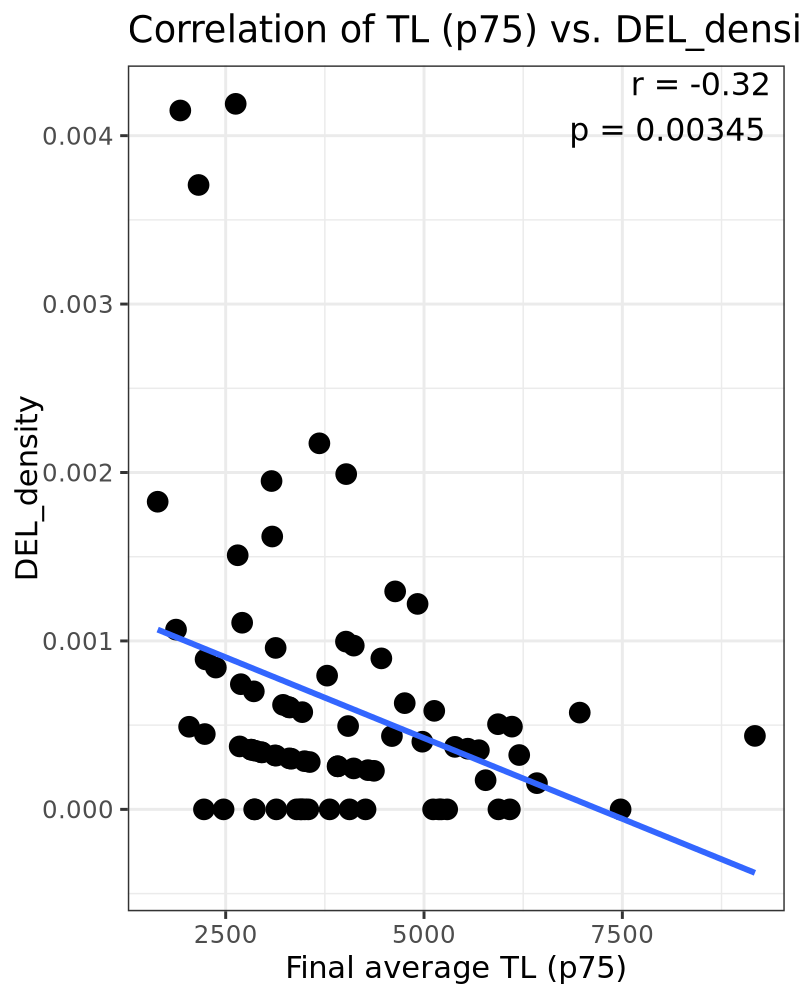

In [296]:
# if you don't already have these:
# install.packages(c("ggplot2"))

library(ggplot2)

# 1) compute correlation
cor_res <- cor.test(final_subset$final_average_TL_p75,
                    final_subset$DUP_density,
                    method = "pearson")

r_val <- cor_res$estimate     # Pearson's r
p_val <- cor_res$p.value      # p‐value

# build annotation string
anno_text <- sprintf("r = %.2f\np = %.3g", r_val, p_val)

options(repr.plot.width = 4, repr.plot.height = 5, repr.plot.res = 200)

# 2) make scatter + fit + annotation
ggplot(final_subset, aes(x = final_average_TL_p75,
                         y = DUP_density)) +
  geom_point(size = 3) +                         # scatter dots
  geom_smooth(method = "lm", se = FALSE) +       # regression line
  annotate("text",
           x = Inf, y = Inf,                     # top‐right
           label = anno_text,
           hjust = 1.1, vjust = 1.1,             # nudge inside
           size = 4) +                           # text size
  labs(
    x = "Final average TL (p75)",
    y = "DEL_density",
    title = "Correlation of TL (p75) vs. DEL_density"
  ) +
  theme_bw()                                     # clean theme
